# Matching Results — Ingredients Analysis

Inspect and analyze `data/matching_results_ingredients.parquet`.

**Schema (× 21 cols)**
| Column | Description |
|---|---|
| `ingredient` | Original ingredient text |
| `level2_code/name/score` | Best FoodEx2 level-2 match |
| `level3_code/name/score` | Best FoodEx2 level-3 match (null when no match at this level) |
| `specific_code/name/score` | Best specific-level match (null when not found) |
| `final_level` | Hierarchy level chosen as the final decision (2 / 3 / 5) |
| `confidence` | HIGH / MEDIUM / LOW / NO_MATCH |
| `top1_code/name/score` | Best match **at the final level** |
| `top2_code/name/score` | Second-best match at the same final level |
| `top3_code/name/score` | Third-best match at the same final level (None when < 3 candidates) |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 60)

PARQUET = '../data/matching_results_ingredients.parquet'
CONFIDENCE_ORDER = ['HIGH', 'MEDIUM', 'LOW', 'NO_MATCH']
CONFIDENCE_COLORS = {'HIGH': '#2ca02c', 'MEDIUM': '#1f77b4', 'LOW': '#ff7f0e', 'NO_MATCH': '#d62728'}

In [2]:
df = pd.read_parquet(PARQUET)
df['confidence'] = pd.Categorical(df['confidence'], categories=CONFIDENCE_ORDER, ordered=True)
print(f'Shape: {df.shape}')
df.head()

Shape: (22824, 21)


,ingredient,level2_code,level2_name,level2_score,level3_code,level3_name,level3_score,specific_code,specific_name,specific_score,...,confidence,top1_code,top1_name,top1_score,top2_code,top2_name,top2_score,top3_code,top3_name,top3_score
0,pasteurised goat milk,A0BXZ,Milk and milk products (dairy),0.851547,A02PD,Milk and dairy powders and concentrates,0.822155,A02PH,Milk and dairy powders,0.853484,...,HIGH,A02PH,Milk and dairy powders,0.853484,A02PE,Milk and dairy concentrate,0.822137,A02PJ,Milk powder,0.800774
1,disaccharide,A0EZH,Nuts and primary derivatives thereof,0.495712,A01BJ,Primary derivatives from nuts and similar seeds,0.430223,None,None,0.000000,...,LOW,A0EZH,Nuts and primary derivatives thereof,0.495712,A0EZN,Fruit and primary derivatives thereof,0.490529,A0BXX,Isolated purified ingredients (including mineral or synthetic),0.487446
2,extract,A0BXX,Isolated purified ingredients (including mineral or synthetic),0.402057,None,None,0.000000,None,None,0.000000,...,NO_MATCH,A0BXX,Isolated purified ingredients (including mineral or synthetic),0.402057,A0EZH,Nuts and primary derivatives thereof,0.285564,A16RE,Starchy roots and tubers and primary derivatives thereof,0.276494
3,whey,A0BXZ,Milk and milk products (dairy),0.356006,None,None,0.000000,None,None,0.000000,...,NO_MATCH,A0BXZ,Milk and milk products (dairy),0.356006,A03LZ,Alcoholic beverages,0.349133,A03TD,Meat and dairy imitates,0.315325
4,lychee flavouring,A0EZM,"Herbs, spices and similar",0.582626,A018Q,Fruit spices,0.637073,A019M,Other fruit spices,0.637039,...,MEDIUM,A018Q,Fruit spices,0.637073,A04MA,Aromatic herbs,0.574412,A04LZ,Aromatic flowers,0.573071


## 1. Overview

In [ ]:
df.dtypes.to_frame('dtype')

In [ ]:
null_summary = df.isnull().sum().rename('null_count').to_frame()
null_summary['pct'] = (null_summary['null_count'] / len(df) * 100).round(1)
null_summary

In [ ]:
df[['level2_score', 'level3_score', 'specific_score', 'top1_score', 'top2_score', 'top3_score']].describe().round(3)

## 2. Confidence Distribution

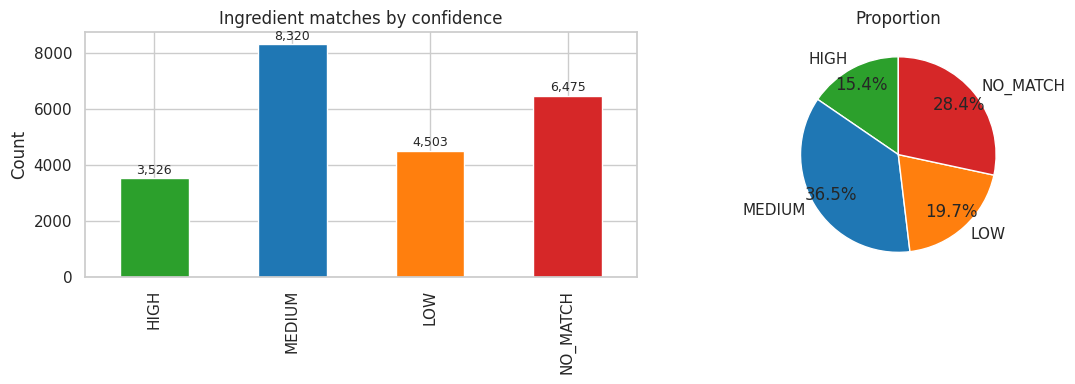

            count   pct
confidence             
HIGH         3526  15.4
MEDIUM       8320  36.5
LOW          4503  19.7
NO_MATCH     6475  28.4


In [3]:
conf_counts = df['confidence'].value_counts().reindex(CONFIDENCE_ORDER)
conf_pct = (conf_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [CONFIDENCE_COLORS[c] for c in CONFIDENCE_ORDER]
conf_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Ingredient matches by confidence')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, conf_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

wedges, texts, autotexts = axes[1].pie(
    conf_counts, labels=CONFIDENCE_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.8
)
axes[1].set_title('Proportion')

plt.tight_layout()
plt.show()

print(pd.DataFrame({'count': conf_counts, 'pct': conf_pct}))

## 3. Score Distributions

/tmp/ipykernel_179767/2724030050.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=['L2', 'L3', 'Specific', 'Top-1 (final)'], patch_artist=True)


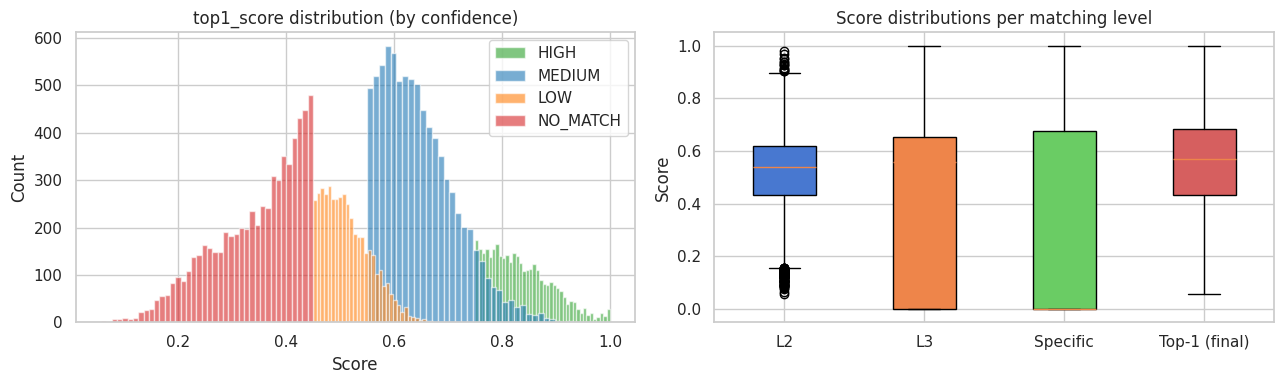

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# top1_score histogram by confidence
for conf in CONFIDENCE_ORDER:
    sub = df[df['confidence'] == conf]['top1_score']
    axes[0].hist(sub, bins=40, alpha=0.6, label=conf, color=CONFIDENCE_COLORS[conf])
axes[0].set_title('top1_score distribution (by confidence)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# score boxplot per level
score_cols = ['level2_score', 'level3_score', 'specific_score', 'top1_score']
data_box = [df[c].dropna() for c in score_cols]
bp = axes[1].boxplot(data_box, labels=['L2', 'L3', 'Specific', 'Top-1 (final)'], patch_artist=True)
palette = sns.color_palette('muted', 4)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
axes[1].set_title('Score distributions per matching level')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [ ]:
# top1_score by confidence — violin
matched = df[df['confidence'] != 'NO_MATCH'].copy()

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(
    data=matched, x='confidence', y='top1_score',
    order=['HIGH', 'MEDIUM', 'LOW'],
    palette=[CONFIDENCE_COLORS[c] for c in ['HIGH', 'MEDIUM', 'LOW']],
    ax=ax, cut=0, inner='box'
)
ax.set_title('top1_score by confidence (matched only)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

matched.groupby('confidence', observed=True)['top1_score'].describe().round(3)

## 4. Matching Level Analysis

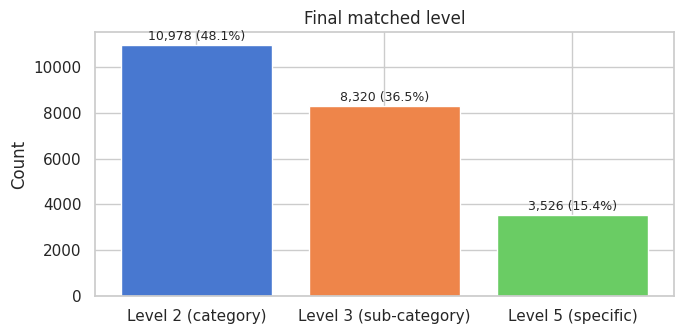

In [5]:
level_counts = df['final_level'].value_counts().sort_index()
level_labels = {2: 'Level 2 (category)', 3: 'Level 3 (sub-category)', 5: 'Level 5 (specific)'}

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(
    [level_labels[l] for l in level_counts.index],
    level_counts.values,
    color=sns.color_palette('muted', len(level_counts))
)
for bar, val in zip(bars, level_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,} ({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Final matched level')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

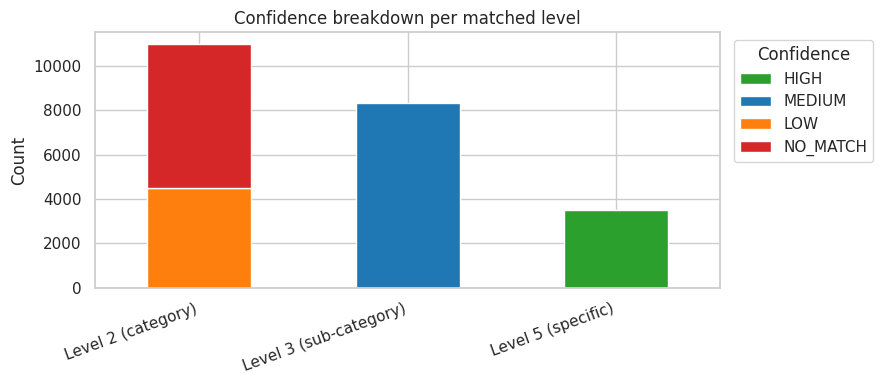

In [6]:
# Confidence split per final_level (stacked bar)
level_conf = (
    df.groupby(['final_level', 'confidence'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CONFIDENCE_ORDER, fill_value=0)
)
level_conf.index = [level_labels[l] for l in level_conf.index]

level_conf.plot(
    kind='bar', stacked=True, figsize=(9, 4),
    color=[CONFIDENCE_COLORS[c] for c in CONFIDENCE_ORDER],
    edgecolor='white'
)
plt.title('Confidence breakdown per matched level')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Confidence', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Top FoodEx2 Categories

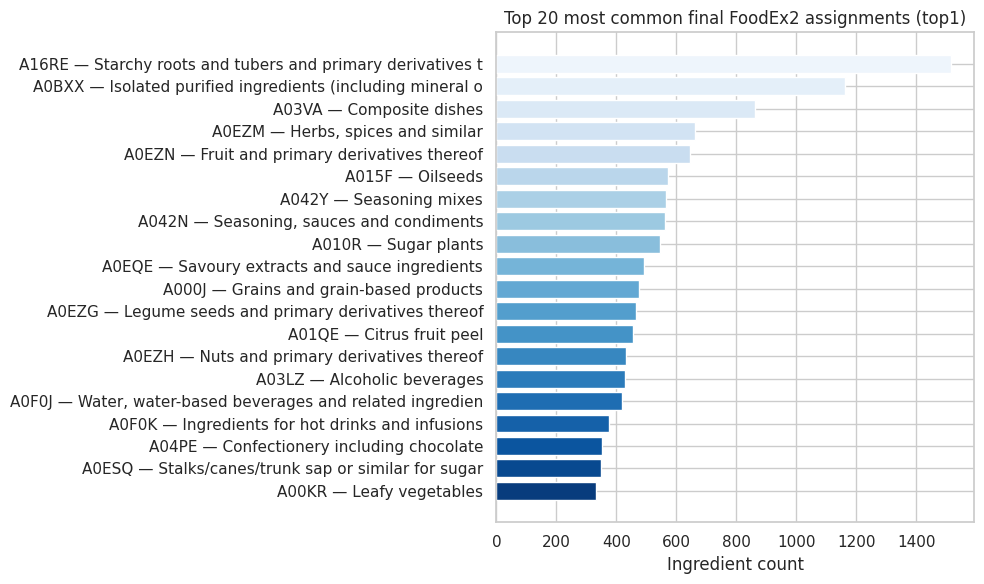

,top1_code,top1_name,count
0,A16RE,Starchy roots and tubers and primary derivatives thereof,1517
1,A0BXX,Isolated purified ingredients (including mineral or synthetic),1164
2,A03VA,Composite dishes,861
3,A0EZM,"Herbs, spices and similar",663
4,A0EZN,Fruit and primary derivatives thereof,645
5,A015F,Oilseeds,571
6,A042Y,Seasoning mixes,567
7,A042N,"Seasoning, sauces and condiments",562
8,A010R,Sugar plants,547
9,A0EQE,Savoury extracts and sauce ingredients,493


In [7]:
top_n = 20

top_final = (
    df.groupby(['top1_code', 'top1_name'], dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index(name='count')
)
top_final['label'] = top_final['top1_code'] + ' — ' + top_final['top1_name'].str[:50]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_final['label'][::-1], top_final['count'][::-1],
               color=sns.color_palette('Blues_r', top_n))
ax.set_title(f'Top {top_n} most common final FoodEx2 assignments (top1)')
ax.set_xlabel('Ingredient count')
plt.tight_layout()
plt.show()

top_final[['top1_code', 'top1_name', 'count']]

In [8]:
# Top level-2 categories
top_l2 = (
    df.groupby(['level2_code', 'level2_name'])
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index(name='count')
)
top_l2

,level2_code,level2_name,count
0,A0EZM,"Herbs, spices and similar",2184
1,A042N,"Seasoning, sauces and condiments",1807
2,A000J,Grains and grain-based products,1688
3,A16RE,Starchy roots and tubers and primary derivatives thereof,1674
4,A0EZN,Fruit and primary derivatives thereof,1576
5,A04PE,Confectionery including chocolate,1318
6,A0BXX,Isolated purified ingredients (including mineral or synthetic),1309
7,A0BXZ,Milk and milk products (dairy),1220
8,A010R,Sugar plants,1071
9,A015E,Oilseeds and oilfruits,1003


## 6. NO_MATCH Inspection

In [ ]:
no_match = df[df['confidence'] == 'NO_MATCH'].copy()
print(f'NO_MATCH rows: {len(no_match):,} ({len(no_match)/len(df)*100:.1f}%)')
no_match[['ingredient', 'level2_code', 'level2_name', 'level2_score']].head(30)

In [ ]:
# Score distribution of no-match group — they still have a level2 match score
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(no_match['top1_score'], bins=40, color='#d62728', alpha=0.7, edgecolor='white')
ax.set_title('NO_MATCH — top1_score distribution')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

no_match['top1_score'].describe().round(3)

In [ ]:
# What level-2 categories are NO_MATCH ingredients being assigned to?
no_match_l2 = (
    no_match.groupby(['level2_code', 'level2_name'])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='count')
)
no_match_l2

## 7. Sample Browser

Quickly inspect rows filtered by confidence / score threshold.

In [ ]:
# --- adjust these parameters ---
FILTER_CONFIDENCE = 'HIGH'   # HIGH | MEDIUM | LOW | NO_MATCH | None (all)
SCORE_MIN = 0.0
SCORE_MAX = 1.0
SAMPLE_N = 20
# --------------------------------

sample = df.copy()
if FILTER_CONFIDENCE:
    sample = sample[sample['confidence'] == FILTER_CONFIDENCE]
sample = sample[(sample['top1_score'] >= SCORE_MIN) & (sample['top1_score'] <= SCORE_MAX)]

cols = ['ingredient', 'top1_code', 'top1_name', 'top2_code', 'top2_name', 'final_level', 'top1_score', 'top2_score', 'confidence']
sample[cols].sample(min(SAMPLE_N, len(sample)), random_state=42)

In [13]:
# Detailed view: show all levels + top-3 candidates for a specific ingredient
INGREDIENT_QUERY = 'water'  # substring search

mask = df['ingredient'].str.contains(INGREDIENT_QUERY, case=False, na=False)
cols_detail = [
    'ingredient',
    'level2_code', 'level2_name', 'level2_score',
    'level3_code', 'level3_name', 'level3_score',
    'final_level', 'confidence',
    'top1_code', 'top1_name', 'top1_score',
    'top2_code', 'top2_name', 'top2_score',
    'top3_code', 'top3_name', 'top3_score',
]
df[mask][cols_detail].head(10)

,ingredient,level2_code,level2_name,level2_score,level3_code,level3_name,level3_score,final_level,confidence,top1_code,top1_name,top1_score,top2_code,top2_name,top2_score,top3_code,top3_name,top3_score
34,lenon juice water,A0F0J,"Water, water-based beverages and related ingredients",0.656378,A03DK,Drinking water,0.597802,3,MEDIUM,A03DK,Drinking water,0.597802,A03FZ,Functional drinks,0.561033,A03GD,Drink mixes,0.555309
165,watermelon flavor,A0F0J,"Water, water-based beverages and related ingredients",0.562003,A0EQN,Soft drinks with minor amounts of fruits or flavours,0.553358,3,MEDIUM,A0EQN,Soft drinks with minor amounts of fruits or flavours,0.553358,A03DK,Drinking water,0.461405,A03FQ,Cola-type drinks,0.430134
370,pork cued with water,A0EZR,Fish meat and products thereof,0.675068,A026V,Fish (meat),0.664650,3,MEDIUM,A026V,Fish (meat),0.664650,A02KB,Processed or preserved fish (including processed offal),0.540533,A02EH,Fish offal,0.527117
595,gravy contains water,A0F0J,"Water, water-based beverages and related ingredients",0.613058,A03GD,Drink mixes,0.555419,3,MEDIUM,A03GD,Drink mixes,0.555419,A03DK,Drinking water,0.479417,A03FZ,Functional drinks,0.460049
675,brine water,A0F0J,"Water, water-based beverages and related ingredients",0.539497,A03DK,Drinking water,0.637196,3,MEDIUM,A03DK,Drinking water,0.637196,A03GD,Drink mixes,0.437904,A03FZ,Functional drinks,0.382200
679,pepper water seven grain,A000J,Grains and grain-based products,0.562131,A0EZF,Cereal grains and similar and primary derivatives thereof,0.526459,2,LOW,A000J,Grains and grain-based products,0.562131,A0EZM,"Herbs, spices and similar",0.536663,A0F0J,"Water, water-based beverages and related ingredients",0.510751
780,rehydrated potato water,A0F0J,"Water, water-based beverages and related ingredients",0.621547,A03DK,Drinking water,0.595606,3,MEDIUM,A03DK,Drinking water,0.595606,A03FZ,Functional drinks,0.486512,A03GD,Drink mixes,0.399936
793,sugr water,A0F0J,"Water, water-based beverages and related ingredients",0.619406,A03DK,Drinking water,0.695976,3,MEDIUM,A03DK,Drinking water,0.695976,A03FZ,Functional drinks,0.481963,A03GD,Drink mixes,0.430949
827,water spirit vinegar,A0F0J,"Water, water-based beverages and related ingredients",0.668675,A03DK,Drinking water,0.557984,3,MEDIUM,A03DK,Drinking water,0.557984,A03GD,Drink mixes,0.550374,A03FZ,Functional drinks,0.517631
904,smoked ham water added,A0F0J,"Water, water-based beverages and related ingredients",0.595038,A03DK,Drinking water,0.481315,2,LOW,A0F0J,"Water, water-based beverages and related ingredients",0.595038,A0EZR,Fish meat and products thereof,0.501334,A0F0K,Ingredients for hot drinks and infusions,0.477998


## 8. Score Threshold Sensitivity

How many ingredients are matched at each confidence level as we vary the score cutoff?

In [ ]:
thresholds = np.arange(0.3, 0.9, 0.02)
records = []
for t in thresholds:
    above = df[df['top1_score'] >= t]
    records.append({
        'threshold': round(t, 2),
        'count': len(above),
        'pct': len(above) / len(df) * 100,
        'HIGH': (above['confidence'] == 'HIGH').sum(),
        'MEDIUM': (above['confidence'] == 'MEDIUM').sum(),
        'LOW': (above['confidence'] == 'LOW').sum(),
    })
sensitivity = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(sensitivity['threshold'], sensitivity['pct'], marker='o', markersize=3)
axes[0].set_title('% ingredients above top1_score threshold')
axes[0].set_xlabel('Min top1_score')
axes[0].set_ylabel('%')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

for col in ['HIGH', 'MEDIUM', 'LOW']:
    axes[1].plot(sensitivity['threshold'], sensitivity[col],
                 label=col, color=CONFIDENCE_COLORS[col], marker='o', markersize=3)
axes[1].set_title('Matched count by confidence above threshold')
axes[1].set_xlabel('Min top1_score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

sensitivity.set_index('threshold').round(1)

## 9. Top-2 / Top-3 Analysis

Each ingredient now carries the **three best candidates at its final matching level**.
`top1` is the chosen match; `top2` and `top3` are runners-up within the same level and
the same hierarchical scope (e.g. if `final_level=3`, all three are children of the same L2 node).

| Analysis | What it tells you |
|---|---|
| **Score gap distributions** | How decisive the top-1 match is — large gap = confident |
| **Ambiguous matches** | Ingredients where top-2 is very close to top-1 — worth manual review |
| **Category agreement** | Whether top-2 belongs to the same FoodEx2 sub-tree as top-1 |
| **Top-3 browser** | Side-by-side view of all three candidates for any ingredient |

/tmp/ipykernel_179767/112910416.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_box, labels=[level_labels.get(lv, str(lv)) for lv in valid_levels], patch_artist=True)


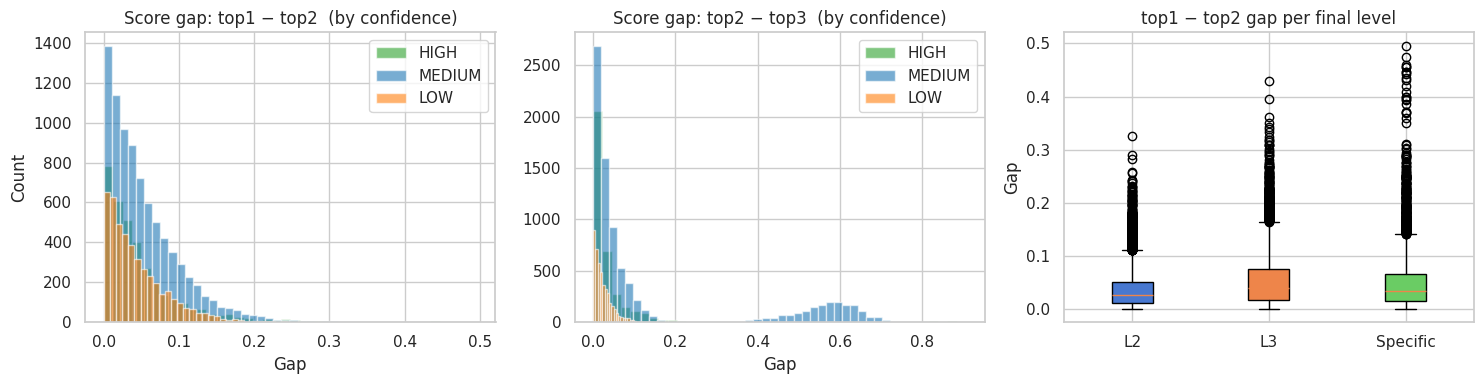

Gap statistics (top1 − top2):


,count,mean,std,min,25%,50%,75%,max
confidence,,,,,,,,
HIGH,3526.0,0.052,0.059,0.0,0.014,0.033,0.065,0.496
MEDIUM,8320.0,0.053,0.049,0.0,0.017,0.040,0.076,0.429
LOW,4503.0,0.045,0.040,0.0,0.014,0.033,0.063,0.325
NO_MATCH,6475.0,0.030,0.028,0.0,0.009,0.022,0.043,0.230


In [9]:
# ── Score gap distributions ──────────────────────────────────────────────────
df['gap_1_2'] = df['top1_score'] - df['top2_score'].fillna(0)
df['gap_2_3'] = df['top2_score'].fillna(0) - df['top3_score'].fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gap 1→2 by confidence
for conf in ['HIGH', 'MEDIUM', 'LOW']:
    sub = df[df['confidence'] == conf]['gap_1_2']
    axes[0].hist(sub, bins=40, alpha=0.6, label=conf, color=CONFIDENCE_COLORS[conf])
axes[0].set_title('Score gap: top1 − top2  (by confidence)')
axes[0].set_xlabel('Gap')
axes[0].set_ylabel('Count')
axes[0].legend()

# Gap 2→3 by confidence
for conf in ['HIGH', 'MEDIUM', 'LOW']:
    sub = df[(df['confidence'] == conf) & df['top2_score'].notna()]['gap_2_3']
    axes[1].hist(sub, bins=40, alpha=0.6, label=conf, color=CONFIDENCE_COLORS[conf])
axes[1].set_title('Score gap: top2 − top3  (by confidence)')
axes[1].set_xlabel('Gap')
axes[1].legend()

# Gap 1→2 boxplot per final_level
level_labels = {0: 'None', 2: 'L2', 3: 'L3', 5: 'Specific'}
valid_levels = sorted(df['final_level'].dropna().unique())
data_box = [df[df['final_level'] == lv]['gap_1_2'].dropna() for lv in valid_levels]
bp = axes[2].boxplot(data_box, labels=[level_labels.get(lv, str(lv)) for lv in valid_levels], patch_artist=True)
palette = sns.color_palette('muted', len(valid_levels))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
axes[2].set_title('top1 − top2 gap per final level')
axes[2].set_ylabel('Gap')

plt.tight_layout()
plt.show()

print('Gap statistics (top1 − top2):')
df.groupby('confidence', observed=True)['gap_1_2'].describe().round(3)

In [10]:
# ── Ambiguous matches: top-2 very close to top-1 ────────────────────────────
# These are the ingredients most worth manual review — the model was uncertain
AMBIGUITY_THRESHOLD = 0.05   # gap < this is considered ambiguous

df['gap_1_2'] = df['top1_score'] - df['top2_score'].fillna(0)
df['gap_2_3'] = df['top2_score'].fillna(0) - df['top3_score'].fillna(0)

ambiguous = df[(df['top2_code'].notna()) & (df['gap_1_2'] < AMBIGUITY_THRESHOLD)].copy()
print(f'Ambiguous matches (gap < {AMBIGUITY_THRESHOLD}): {len(ambiguous):,} ({len(ambiguous)/len(df)*100:.1f}%)')

amb_cols = [
    'ingredient', 'confidence', 'final_level',
    'top1_code', 'top1_name', 'top1_score',
    'top2_code', 'top2_name', 'top2_score',
    'gap_1_2',
]
ambiguous.sort_values('gap_1_2')[amb_cols].head(25)

Ambiguous matches (gap < 0.05): 15,350 (67.3%)


,ingredient,confidence,final_level,top1_code,top1_name,top1_score,top2_code,top2_name,top2_score,gap_1_2
13444,vitamin d3 sugar,NO_MATCH,2,A010R,Sugar plants,0.434479,A0EZN,Fruit and primary derivatives thereof,0.434478,4.172325e-07
9001,spanish olives,HIGH,5,A016M,Olives for oil production,0.811602,A0DAM,Olives for oil production and similar-,0.811599,2.622604e-06
17824,phone 371,NO_MATCH,2,A0EZH,Nuts and primary derivatives thereof,0.087287,A042N,"Seasoning, sauces and condiments",0.087283,4.500151e-06
14686,artificial vanilla,LOW,2,A04PE,Confectionery including chocolate,0.476886,A0BXX,Isolated purified ingredients (including mineral or synthetic),0.476881,5.006790e-06
11604,potassi sodium citrate,NO_MATCH,2,A0BXX,Isolated purified ingredients (including mineral or synthetic),0.397272,A16RE,Starchy roots and tubers and primary derivatives thereof,0.397267,5.424023e-06
11212,phosoplonic acid,NO_MATCH,2,A0EZG,Legume seeds and primary derivatives thereof,0.371648,A0EZH,Nuts and primary derivatives thereof,0.371641,6.914139e-06
21866,seabuckthorn powder,LOW,2,A0EZM,"Herbs, spices and similar",0.483840,A0F0J,"Water, water-based beverages and related ingredients",0.483833,7.241964e-06
12162,please keep refrigerated,NO_MATCH,2,A0EZP,"Fruit/vegetables/plant drinks, spreads and related products",0.399641,A03PV,Food products for young population,0.399633,8.344650e-06
14608,pancake flakes,LOW,2,A04PE,Confectionery including chocolate,0.459285,A03VA,Composite dishes,0.459275,1.031160e-05
10793,enriched with 25 cherries,LOW,2,A015E,Oilseeds and oilfruits,0.489767,A0EZN,Fruit and primary derivatives thereof,0.489752,1.463294e-05


Top-2 category agreement (same first-4-char prefix as top1):


,agree,total,agree_pct
confidence,,,
HIGH,1536,3526,43.6
MEDIUM,1112,8320,13.4
LOW,489,4503,10.9
NO_MATCH,647,6475,10.0


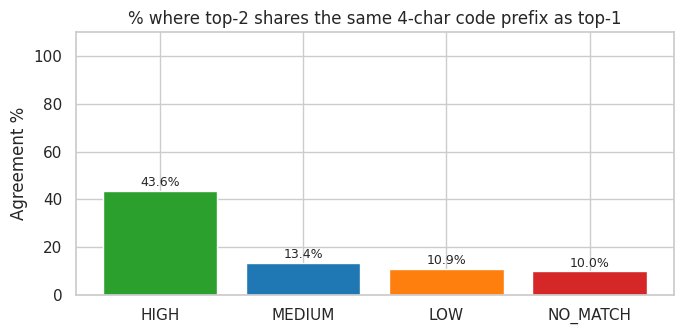

In [11]:
# ── Category agreement: does top2 agree with top1? ─────────────────────────
# "agree" = same FoodEx2 code prefix (first 4 chars covers the sub-category root)
PREFIX_LEN = 4

has_top2 = df['top2_code'].notna()
agree = df.loc[has_top2].copy()
agree['top1_prefix'] = agree['top1_code'].str[:PREFIX_LEN]
agree['top2_prefix'] = agree['top2_code'].str[:PREFIX_LEN]
agree['prefix_match'] = agree['top1_prefix'] == agree['top2_prefix']

agreement_by_conf = (
    agree.groupby('confidence', observed=True)['prefix_match']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'agree', 'count': 'total'})
)
agreement_by_conf['agree_pct'] = (agreement_by_conf['agree'] / agreement_by_conf['total'] * 100).round(1)
print('Top-2 category agreement (same first-4-char prefix as top1):')
display(agreement_by_conf)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors_bar = [CONFIDENCE_COLORS[c] for c in agreement_by_conf.index]
bars = ax.bar(agreement_by_conf.index, agreement_by_conf['agree_pct'], color=colors_bar, edgecolor='white')
for bar, pct in zip(bars, agreement_by_conf['agree_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 110)
ax.set_title(f'% where top-2 shares the same {PREFIX_LEN}-char code prefix as top-1')
ax.set_ylabel('Agreement %')
plt.tight_layout()
plt.show()

In [12]:
# ── Top-3 side-by-side browser ──────────────────────────────────────────────
# Set INGREDIENT_QUERY to inspect a specific ingredient (or leave empty for random sample)
INGREDIENT_QUERY = ''     # substring match; leave '' for a random sample
SAMPLE_N_TOP3 = 15
FILTER_CONF_TOP3 = None   # 'HIGH' | 'MEDIUM' | 'LOW' | 'NO_MATCH' | None (all)

browser = df.copy()
if INGREDIENT_QUERY:
    browser = browser[browser['ingredient'].str.contains(INGREDIENT_QUERY, case=False, na=False)]
if FILTER_CONF_TOP3:
    browser = browser[browser['confidence'] == FILTER_CONF_TOP3]

top3_cols = [
    'ingredient', 'final_level', 'confidence',
    'top1_code', 'top1_name', 'top1_score',
    'top2_code', 'top2_name', 'top2_score',
    'top3_code', 'top3_name', 'top3_score',
]
browser[top3_cols].sample(min(SAMPLE_N_TOP3, len(browser)), random_state=0)

,ingredient,final_level,confidence,top1_code,top1_name,top1_score,top2_code,top2_name,top2_score,top3_code,top3_name,top3_score
8960,lait ecreme condense eau sucre,3,MEDIUM,A02MP,Flavoured milks,0.767641,A065H,Baked milk and similar,0.752544,A0C69,Fermented milk products,0.750924
4367,polyglyceroid polyricinoleate,2,NO_MATCH,A0EZG,Legume seeds and primary derivatives thereof,0.391740,A16RE,Starchy roots and tubers and primary derivatives thereof,0.371969,A0EZH,Nuts and primary derivatives thereof,0.360941
1086,pure and natural honey,2,LOW,A0BXX,Isolated purified ingredients (including mineral or synthetic),0.515256,A0EZM,"Herbs, spices and similar",0.500898,A0BXZ,Milk and milk products (dairy),0.455338
6771,potassium sorbate for freshness,2,LOW,A0EZM,"Herbs, spices and similar",0.529921,A0BXX,Isolated purified ingredients (including mineral or synthetic),0.509248,A0F0K,Ingredients for hot drinks and infusions,0.502994
12143,starter,2,NO_MATCH,A03VA,Composite dishes,0.293571,A0EZG,Legume seeds and primary derivatives thereof,0.289657,A16RE,Starchy roots and tubers and primary derivatives thereof,0.241741
21951,natural aroma of vanilla,3,MEDIUM,A04MA,Aromatic herbs,0.697574,A04LZ,Aromatic flowers,0.635747,A01AK,Bud spices,0.548173
9262,green and serves 3,2,LOW,A03VA,Composite dishes,0.476426,A031E,Eggs and egg products,0.453774,A0EZP,"Fruit/vegetables/plant drinks, spreads and related products",0.441501
15932,rajgira,3,MEDIUM,A01AT,Aril spices,0.637201,A019Z,Root and rhizome spices,0.628838,A018Q,Fruit spices,0.600323
14801,mustard flavour seasoning,3,MEDIUM,A042Y,Seasoning mixes,0.710146,A0EQE,Savoury extracts and sauce ingredients,0.685864,A046F,Dessert sauces/toppings,0.602724
1180,vanilla liqueur,3,MEDIUM,A16RG,Edible alcohol,0.617480,A03MS,Wine and wine-like drinks,0.581718,A03PM,Mixed alcoholic drinks,0.563020
